## Part 1: Environment Setup & Validation

### 1.1 Installation
Jupyter magic commands install into the same kernel the notebook is running in
(unlike `!pip`, which may hit a different interpreter).

In [4]:
%pip install opencv-python
%pip install matplotlib
%pip install numpy pandas
%pip install cv2


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


### 1.2 Import & Validate

Matplotlib is building the font cache; this may take a moment.


OpenCV version: 5.0.0
NumPy version : 2.3.5
Pandas version: 2.3.3


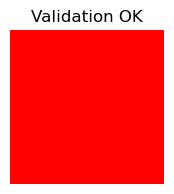

Environment validated: cv2 and matplotlib are working.


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Quick validation: build a tiny array, push it through one OpenCV call and one plot call.
print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)
print("Pandas version:", pd.__version__)

_test = np.zeros((10, 10, 3), dtype=np.uint8)
_test[:, :, 2] = 255                      # pure red in BGR
_converted = cv2.cvtColor(_test, cv2.COLOR_BGR2RGB)
assert _converted[0, 0].tolist() == [255, 0, 0], "cvtColor did not behave as expected"

plt.figure(figsize=(2, 2))
plt.imshow(_converted)
plt.axis('off')
plt.title('Validation OK')
plt.show()

print("Environment validated: cv2 and matplotlib are working.")

## Part 2: Python Data Structures & Logic

### Task 1: Object-Oriented Grocery Manager

In [3]:
class GroceryManager:
    # Manages a grocery list where each item maps to its quantity and unit price.

    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        if not isinstance(quantity, (int, float)) or quantity <= 0:
            print(f"Error: quantity for '{item}' must be a positive number.")
            return False
        if not isinstance(price, (int, float)) or price < 0:
            print(f"Error: price for '{item}' cannot be negative.")
            return False

        if item in self.items:
            # Already on the list -> top up the quantity and refresh the price.
            self.items[item]['quantity'] += quantity
            self.items[item]['price'] = price
            print(f"Updated '{item}': quantity is now {self.items[item]['quantity']}.")
        else:
            self.items[item] = {'quantity': quantity, 'price': price}
            print(f"Added '{item}' x{quantity} @ {price:.2f} each.")
        return True

    def remove_item(self, item):
        # Basic error handling: refuse to remove something that isn't there.
        if item not in self.items:
            print(f"Error: '{item}' is not in the grocery list, nothing removed.")
            return False
        del self.items[item]
        print(f"Removed '{item}'.")
        return True

    def view_list(self):
        if not self.items:
            print("The grocery list is empty.")
            return

        print("\n--- Grocery List ---")
        print(f"{'Item':<15}{'Qty':>6}{'Price':>10}{'Subtotal':>12}")
        print("-" * 43)
        for name, info in self.items.items():
            subtotal = info['quantity'] * info['price']
            print(f"{name:<15}{info['quantity']:>6}{info['price']:>10.2f}{subtotal:>12.2f}")
        print("-" * 43)
        print(f"{'TOTAL':<15}{'':>6}{'':>10}{self.calculate_total():>12.2f}\n")

    def calculate_total(self):
        return sum(info['quantity'] * info['price'] for info in self.items.values())


# --- Demo ---
manager = GroceryManager()
manager.add_item("Milk", 2, 280.00)
manager.add_item("Bread", 1, 150.00)
manager.add_item("Eggs", 12, 25.00)
manager.add_item("Rice", 5, 210.50)

manager.view_list()

manager.remove_item("Chocolate")   # not in the list -> handled error
manager.remove_item("Bread")       # valid removal

manager.view_list()
print(f"Total cost of all items: {manager.calculate_total():.2f}")

Added 'Milk' x2 @ 280.00 each.
Added 'Bread' x1 @ 150.00 each.
Added 'Eggs' x12 @ 25.00 each.
Added 'Rice' x5 @ 210.50 each.

--- Grocery List ---
Item              Qty     Price    Subtotal
-------------------------------------------
Milk                2    280.00      560.00
Bread               1    150.00      150.00
Eggs               12     25.00      300.00
Rice                5    210.50     1052.50
-------------------------------------------
TOTAL                               2062.50

Error: 'Chocolate' is not in the grocery list, nothing removed.
Removed 'Bread'.

--- Grocery List ---
Item              Qty     Price    Subtotal
-------------------------------------------
Milk                2    280.00      560.00
Eggs               12     25.00      300.00
Rice                5    210.50     1052.50
-------------------------------------------
TOTAL                               1912.50

Total cost of all items: 1912.50


### Task 2: Advanced Student Record System

In [4]:
students = {
    "S001": {"Name": "Ayesha Khan",   "Major": "Artificial Intelligence", "Grades": [88, 92, 79, 95]},
    "S002": {"Name": "Bilal Ahmed",   "Major": "Computer Science",        "Grades": [72, 68, 80, 75]},
    "S003": {"Name": "Fatima Noor",   "Major": "Artificial Intelligence", "Grades": [95, 91, 98, 89]},
    "S004": {"Name": "Hamza Raza",    "Major": "Software Engineering",    "Grades": [60, 74, 66, 71]},
    "S005": {"Name": "Zara Siddiqui", "Major": "Computer Science",        "Grades": [84, 87, 90, 82]},
}


def top_student(records):
    # Returns the name of the student with the highest average grade.
    if not records:
        print("Error: the record system is empty.")
        return None

    best_name = None
    best_average = float('-inf')

    for student_id, info in records.items():
        grades = info.get('Grades', [])
        if not grades:
            print(f"Warning: {info.get('Name', student_id)} has no grades, skipping.")
            continue
        average = sum(grades) / len(grades)
        if average > best_average:
            best_average = average
            best_name = info['Name']

    if best_name is None:
        print("Error: no student had any grades recorded.")
        return None

    print(f"Highest average: {best_name} ({best_average:.2f})")
    return best_name


def search_by_major(records, major):
    # Prints every student enrolled in the given major (case-insensitive match).
    target = major.strip().lower()
    matches = [info for info in records.values() if info['Major'].strip().lower() == target]

    if not matches:
        print(f"No students found in major '{major}'.")
        return []

    print(f"\nStudents enrolled in '{major}':")
    for info in matches:
        average = sum(info['Grades']) / len(info['Grades']) if info['Grades'] else 0
        print(f"  - {info['Name']:<15} (avg: {average:.2f})")
    return matches


top_student(students)
search_by_major(students, "Artificial Intelligence")
search_by_major(students, "Data Science")   # no match -> handled

Highest average: Fatima Noor (93.25)

Students enrolled in 'Artificial Intelligence':
  - Ayesha Khan     (avg: 88.50)
  - Fatima Noor     (avg: 93.25)
No students found in major 'Data Science'.


[]

## Part 3: Core Computer Vision & Matplotlib

> All image visualization tasks use Matplotlib subplots for side-by-side comparisons unless stated otherwise.

### Image paths and safe loader

Edit `IMAGE_PATH`, `HIGH_RES_PATH`, `DOC_PATH`, `IMAGE_A`, `IMAGE_B` to point at your own files.

In [7]:
IMAGE_PATH    = r'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg'      # Task 3
HIGH_RES_PATH = r'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg'    # Task 5 (use a large image if you have one)
CAPTION_PATH  = r'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg'      # Task 6
DOC_PATH      = r'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg'     # Task 7 (grayscale document / high-contrast image)
IMAGE_A       = r'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg'      # Task 8
IMAGE_B       = r'C:\Users\Student2026\Desktop\New folder\StalinCropped1943.jpg'       # Task 8


def make_sample_image(width=800, height=600, seed=0):
    # Generates a synthetic BGR image so every cell runs even without your own files.
    yy, xx = np.mgrid[0:height, 0:width]
    b = (255 * (xx / max(width - 1, 1))).astype(np.uint8)
    g = (255 * (yy / max(height - 1, 1))).astype(np.uint8)
    r = (127 + 127 * np.sin(2 * np.pi * (xx + yy) / (90 + 30 * seed))).astype(np.uint8)
    img = np.dstack([b, g, r])

    # A few hard-edged shapes so blurring and thresholding have something to act on.
    cv2.circle(img, (width // 2, height // 2), min(width, height) // 4, (255, 255, 255), -1)
    cv2.rectangle(img, (40, 40), (width // 4, height // 4), (0, 0, 0), -1)
    cv2.putText(img, "SAMPLE", (int(0.22 * width), int(0.88 * height)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 5)
    return img


def load_image_safe(path, fallback=True, **kwargs):
    # Implements the required safety check, with an optional generated fallback.
    image = cv2.imread(path)
    if image is None:
        print(f"Error: Image not found.  (looked for: {path})")
        if fallback:
            print("  -> Substituting a generated sample image so the cell still runs.")
            return make_sample_image(**kwargs)
        return None
    print(f"Loaded '{path}' with shape {image.shape}")
    return image

### Task 3: Safe Image Loading & RGB Visualization

OpenCV reads images in **BGR** order; Matplotlib expects **RGB**, so displaying an
unconverted OpenCV image shows inverted colors (reds and blues swapped).

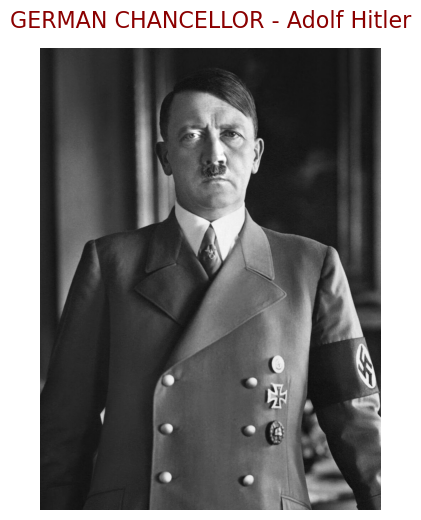

In [9]:
image = cv2.imread(IMAGE_PATH)

if image is None:
    print("Error: Image not found.")
    print("  -> Substituting a generated sample image for demonstration.")
    image = make_sample_image()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('GERMAN CHANCELLOR - Adolf Hitler', fontsize=16, color='darkred', pad=15)
plt.show()

**Optional demonstration of the BGR/RGB problem** — the same array with and without conversion.

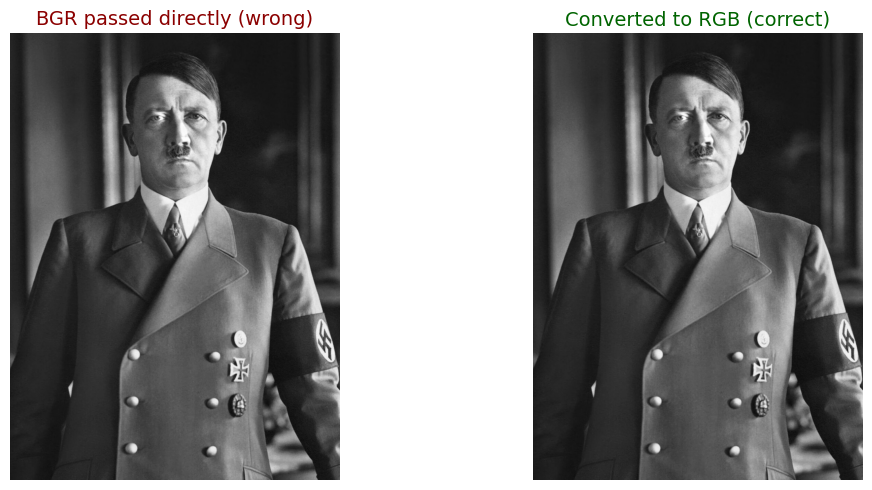

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)          # raw BGR handed to Matplotlib -> wrong colors
axes[0].set_title('BGR passed directly (wrong)', fontsize=14, color='darkred')
axes[0].axis('off')

axes[1].imshow(image_rgb)      # converted -> correct colors
axes[1].set_title('Converted to RGB (correct)', fontsize=14, color='darkgreen')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 4: Interactive Geometry & Blank Canvas

An 800x800 black canvas, a five-ring target board in alternating colors, a bounding box
around the outermost ring, and the exact center coordinates printed.

Canvas size          : 800 x 800
Exact center (x, y)  : (400, 400)
Outer circle radius  : 350
Bounding box         : top-left (50, 50), bottom-right (750, 750)


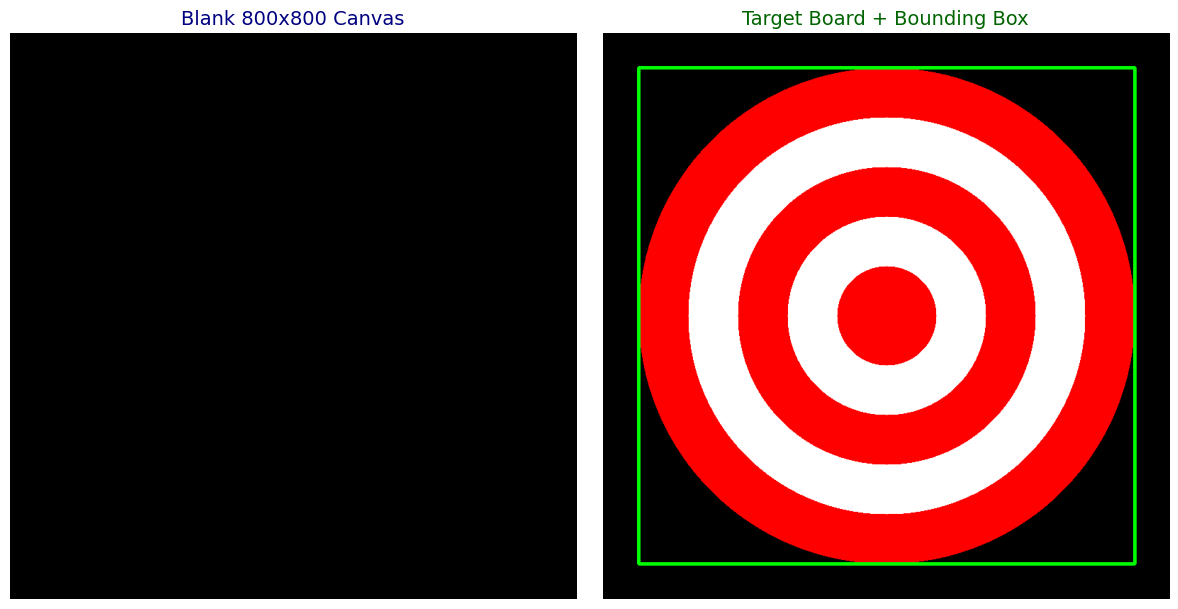

In [11]:
CANVAS_SIZE = 800
canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8)

center_x = CANVAS_SIZE // 2
center_y = CANVAS_SIZE // 2
center = (center_x, center_y)

# Five concentric circles, drawn largest first so smaller ones sit on top.
# Colors are BGR tuples, alternating red / white.
radii  = [350, 280, 210, 140, 70]
colors = [(0, 0, 255), (255, 255, 255), (0, 0, 255), (255, 255, 255), (0, 0, 255)]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=-1)   # -1 = filled

# Bounding box around the outermost circle.
outer_radius = radii[0]
top_left     = (center_x - outer_radius, center_y - outer_radius)
bottom_right = (center_x + outer_radius, center_y + outer_radius)
cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), thickness=4)

print(f"Canvas size          : {CANVAS_SIZE} x {CANVAS_SIZE}")
print(f"Exact center (x, y)  : {center}")
print(f"Outer circle radius  : {outer_radius}")
print(f"Bounding box         : top-left {top_left}, bottom-right {bottom_right}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8))
axes[0].set_title('Blank 800x800 Canvas', fontsize=14, color='navy')
axes[0].axis('off')

axes[1].imshow(canvas_rgb)
axes[1].set_title('Target Board + Bounding Box', fontsize=14, color='darkgreen')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction

A 25x25 Gaussian kernel (odd sizes are required by `cv2.GaussianBlur`), then a
300x300 center crop taken from both the original and the blurred image via array slicing.

Loaded 'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg' with shape (1302, 960, 3)
Full image      : 960 x 1302
ROI slice rows  : 501:801
ROI slice cols  : 330:630
ROI shape       : (300, 300, 3)


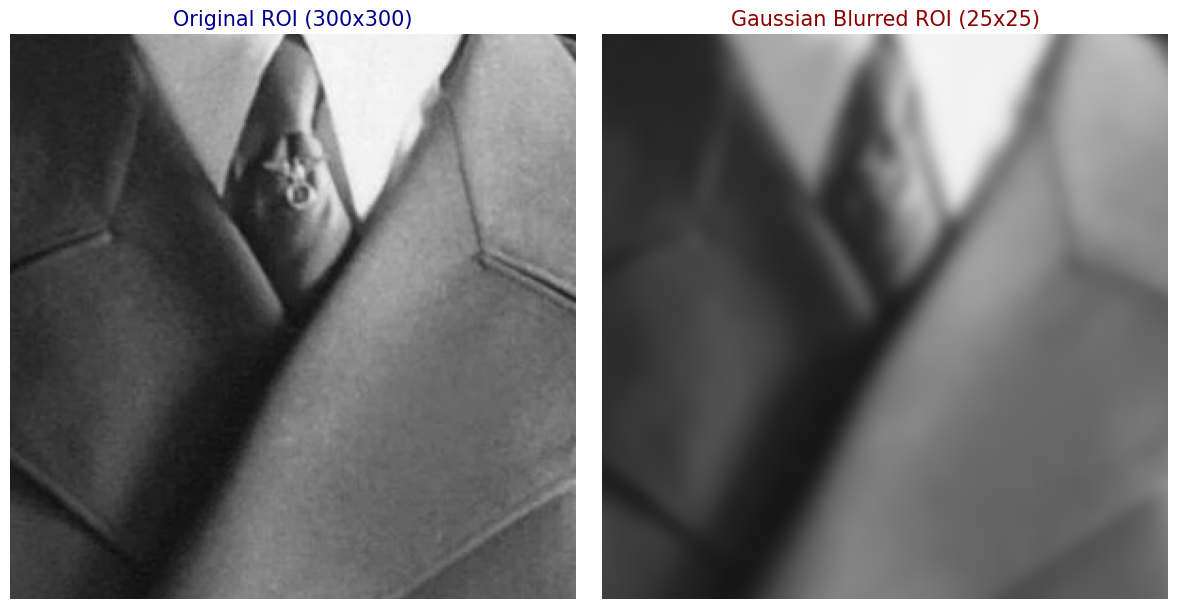

In [12]:
hi_res = load_image_safe(HIGH_RES_PATH, width=1200, height=900)
hi_res_rgb = cv2.cvtColor(hi_res, cv2.COLOR_BGR2RGB)

# Heavy Gaussian blur. Kernel dimensions must be positive and odd.
blurred_rgb = cv2.GaussianBlur(hi_res_rgb, (25, 25), 0)

ROI_SIZE = 300
h, w = hi_res_rgb.shape[:2]

if h < ROI_SIZE or w < ROI_SIZE:
    raise ValueError(f"Image is {w}x{h}; needs to be at least {ROI_SIZE}x{ROI_SIZE} for the ROI.")

# Exact-center slice bounds.
start_y = (h - ROI_SIZE) // 2
start_x = (w - ROI_SIZE) // 2
end_y   = start_y + ROI_SIZE
end_x   = start_x + ROI_SIZE

roi_original = hi_res_rgb[start_y:end_y, start_x:end_x]
roi_blurred  = blurred_rgb[start_y:end_y, start_x:end_x]

print(f"Full image      : {w} x {h}")
print(f"ROI slice rows  : {start_y}:{end_y}")
print(f"ROI slice cols  : {start_x}:{end_x}")
print(f"ROI shape       : {roi_original.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(roi_original)
axes[0].set_title('Original ROI (300x300)', fontsize=15, color='darkblue')
axes[0].axis('off')

axes[1].imshow(roi_blurred)
axes[1].set_title('Gaussian Blurred ROI (25x25)', fontsize=15, color='darkred')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 6: Alpha Blending & Typography

A blue bar over the bottom 20% of the image, blended semi-transparently with
`cv2.addWeighted`, with a caption written over it.

Loaded 'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg' with shape (1302, 960, 3)


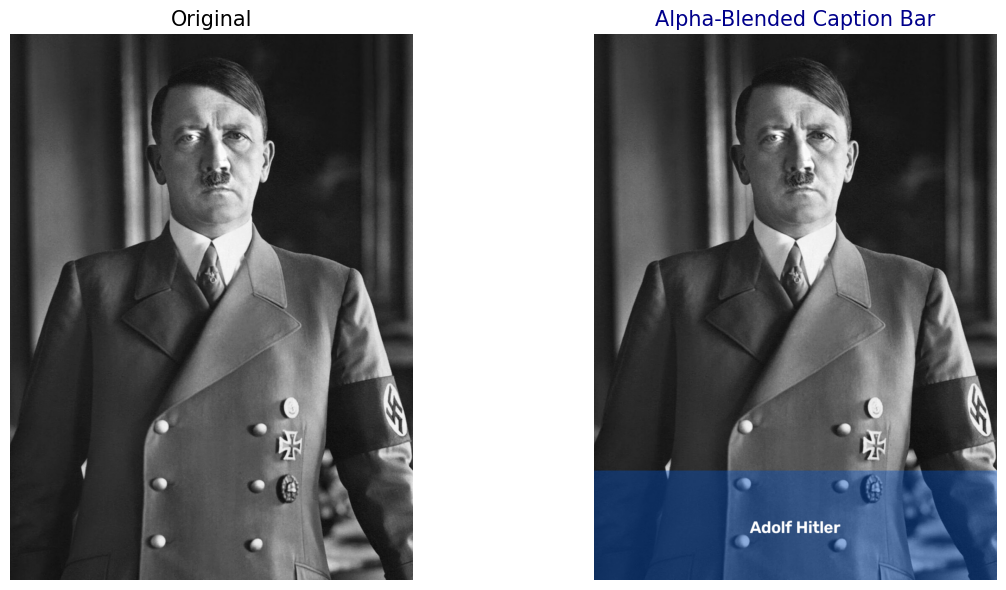

In [14]:
caption_img = load_image_safe(CAPTION_PATH)
caption_img = caption_img.copy()
h, w = caption_img.shape[:2]

# Solid color overlay: same size as the image, with a filled rectangle over the bottom 20%.
overlay = caption_img.copy()
bar_top = int(h * 0.80)
cv2.rectangle(overlay, (0, bar_top), (w, h), (200, 80, 0), thickness=-1)   # BGR blue

# Semi-transparent blend: alpha on the original, beta on the overlay.
alpha = 0.6
beta  = 1 - alpha
blended = cv2.addWeighted(caption_img, alpha, overlay, beta, 0)

# Caption text over the transparent box.
text = "Adolf Hitler"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = max(w / 700.0, 0.6)
thickness = max(int(font_scale * 2), 1)

(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
text_x = (w - text_w) // 2
text_y = bar_top + (h - bar_top + text_h) // 2

cv2.putText(blended, text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(cv2.cvtColor(caption_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=15, color='black')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[1].set_title('Alpha-Blended Caption Bar', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

Global binary thresholding uses one cutoff for the whole image; adaptive thresholding
computes a separate cutoff per neighbourhood, which handles uneven lighting far better.
The adaptive output is then rotated 45 degrees with a scale factor of 0.8 so the
corners stay inside the frame.

Loaded 'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg' with shape (1302, 960, 3)


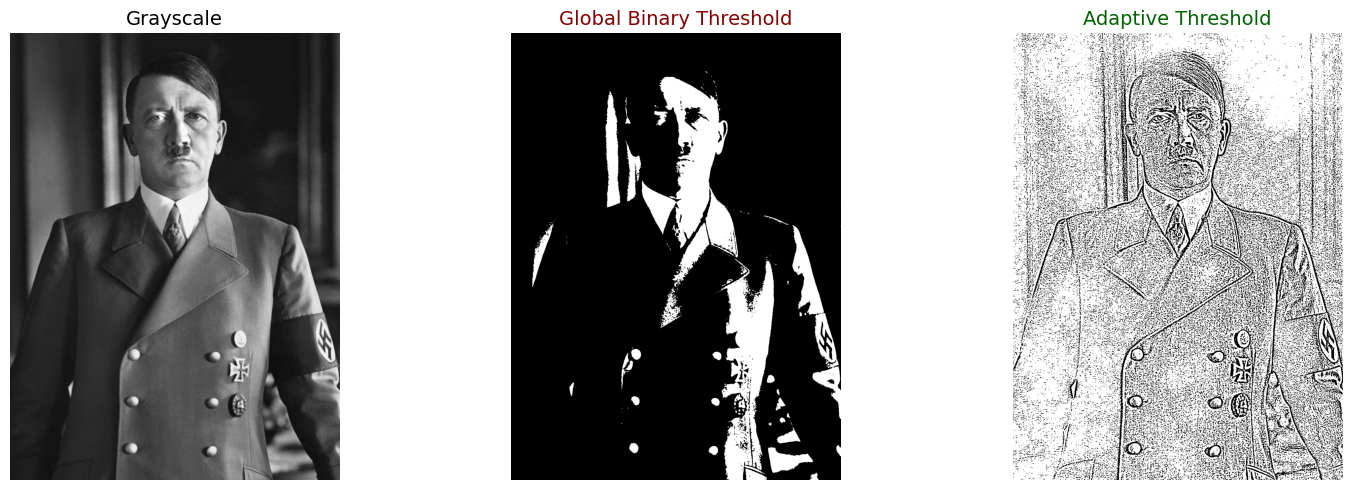

In [15]:
doc = load_image_safe(DOC_PATH, width=800, height=600, seed=1)
gray = cv2.cvtColor(doc, cv2.COLOR_BGR2GRAY)

# 1) Global binary threshold - single cutoff at 127.
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2) Adaptive threshold - cutoff computed per 11x11 neighbourhood, minus a constant of 2.
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale', fontsize=14, color='black')
axes[0].axis('off')

axes[1].imshow(global_thresh, cmap='gray')
axes[1].set_title('Global Binary Threshold', fontsize=14, color='darkred')
axes[1].axis('off')

axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold', fontsize=14, color='darkgreen')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Rotation matrix (2x3):
[[   0.5657    0.5657 -159.7902]
 [  -0.5657    0.5657  554.2678]]


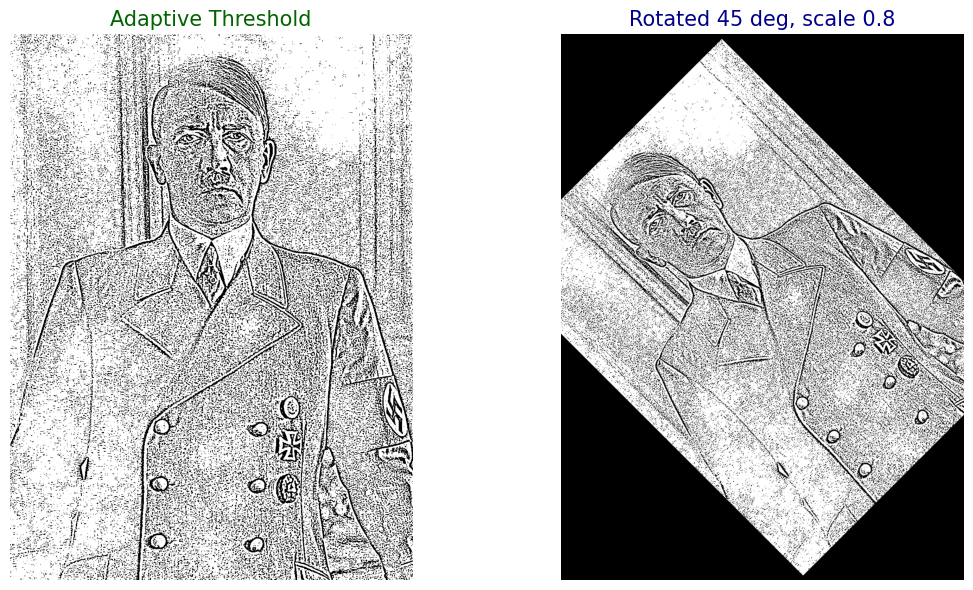

In [16]:
# Rotate the adaptive threshold output by exactly 45 degrees, scaled by 0.8.
rows, cols = adaptive_thresh.shape
rotation_center = (cols / 2.0, rows / 2.0)

rotation_matrix = cv2.getRotationMatrix2D(rotation_center, angle=45, scale=0.8)
print("Rotation matrix (2x3):")
print(np.round(rotation_matrix, 4))

rotated = cv2.warpAffine(
    adaptive_thresh,
    rotation_matrix,
    (cols, rows),
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(adaptive_thresh, cmap='gray')
axes[0].set_title('Adaptive Threshold', fontsize=15, color='darkgreen')
axes[0].axis('off')

axes[1].imshow(rotated, cmap='gray')
axes[1].set_title('Rotated 45 deg, scale 0.8', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 8: Masking with Bitwise Logic

The foreground shape is cut from image A, the background is cut from image B using the
inverted mask, and the two disjoint halves are recombined with `cv2.bitwise_or`.

Loaded 'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg' with shape (1302, 960, 3)
Loaded 'C:\Users\Student2026\Desktop\New folder\StalinCropped1943.jpg' with shape (1280, 960, 3)


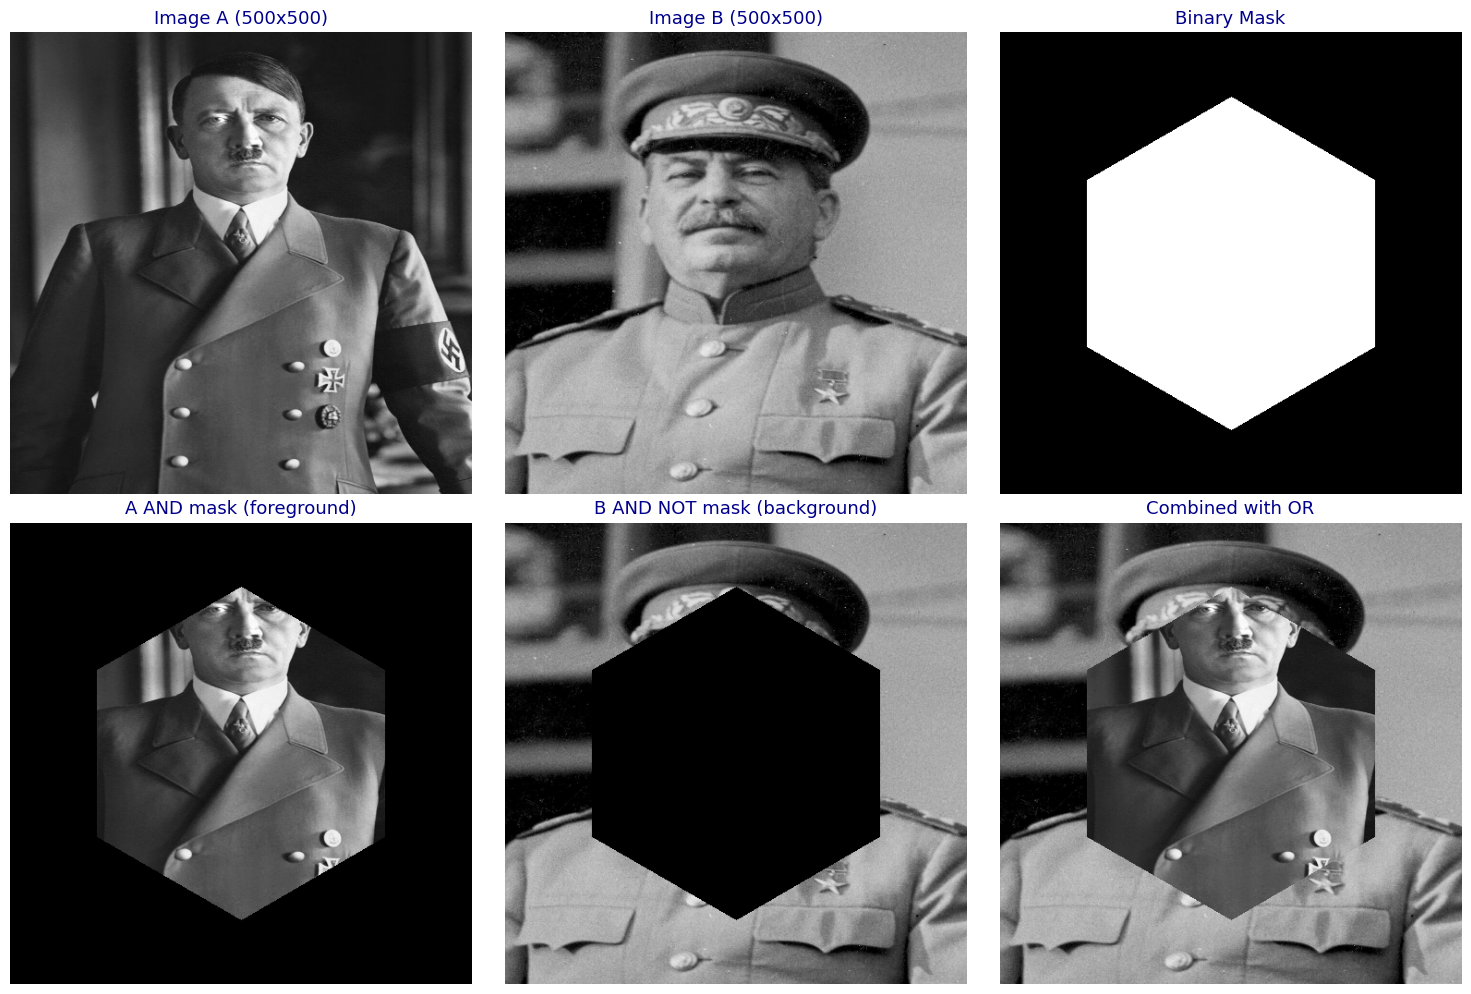

In [17]:
SIZE = 500

img_a = cv2.resize(load_image_safe(IMAGE_A, width=900, height=700, seed=0), (SIZE, SIZE))
img_b = cv2.resize(load_image_safe(IMAGE_B, width=900, height=700, seed=2), (SIZE, SIZE))

# Binary mask: black canvas with a thick white polygon (hexagon) in the center.
mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
cx, cy, radius = SIZE // 2, SIZE // 2, 180
angles = np.linspace(0, 2 * np.pi, 6, endpoint=False) - np.pi / 2
polygon = np.array([[int(cx + radius * np.cos(a)), int(cy + radius * np.sin(a))] for a in angles],
                   dtype=np.int32)
cv2.fillPoly(mask, [polygon], 255)

mask_inv = cv2.bitwise_not(mask)

# Foreground from image A (inside the polygon), background from image B (outside it).
foreground = cv2.bitwise_and(img_a, img_a, mask=mask)
background = cv2.bitwise_and(img_b, img_b, mask=mask_inv)
combined   = cv2.bitwise_or(foreground, background)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

panels = [
    (cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB), 'Image A (500x500)', None),
    (cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB), 'Image B (500x500)', None),
    (mask, 'Binary Mask', 'gray'),
    (cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB), 'A AND mask (foreground)', None),
    (cv2.cvtColor(background, cv2.COLOR_BGR2RGB), 'B AND NOT mask (background)', None),
    (cv2.cvtColor(combined, cv2.COLOR_BGR2RGB), 'Combined with OR', None),
]

for ax, (data, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=13, color='darkblue')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Task 9: Statistical Image Profiling with Pandas

Each channel is flattened from a 2D array into a 1D array, the three are loaded into a
DataFrame, and `.describe()` reports count, mean, std, min, quartiles and max per channel.

In [18]:
profile_img = load_image_safe(IMAGE_PATH)
profile_rgb = cv2.cvtColor(profile_img, cv2.COLOR_BGR2RGB)

# Split the channels and flatten each 2D array into 1D.
red_channel   = profile_rgb[:, :, 0].flatten()
green_channel = profile_rgb[:, :, 1].flatten()
blue_channel  = profile_rgb[:, :, 2].flatten()

print(f"Image shape        : {profile_rgb.shape}")
print(f"Pixels per channel : {red_channel.shape[0]}")

df = pd.DataFrame({
    'Red':   red_channel,
    'Green': green_channel,
    'Blue':  blue_channel
})

print("\nFirst five pixels:")
print(df.head())

print("\n--- Statistical Summary (.describe()) ---")
print(df.describe())

# The specific figures the task asks for, pulled out individually.
print("\n--- Requested statistics ---")
for channel in ['Red', 'Green', 'Blue']:
    col = df[channel]
    print(f"{channel:<6} mean={col.mean():7.2f}  min={col.min():4d}  "
          f"max={col.max():4d}  std={col.std():7.2f}")

Loaded 'C:\Users\Student2026\Desktop\New folder\Hitler_portrait_crop_(cropped)(2).jpg' with shape (1302, 960, 3)
Image shape        : (1302, 960, 3)
Pixels per channel : 1249920

First five pixels:
   Red  Green  Blue
0   37     37    37
1   37     37    37
2   36     36    36
3   37     37    37
4   37     37    37

--- Statistical Summary (.describe()) ---
                Red         Green          Blue
count  1.249920e+06  1.249920e+06  1.249920e+06
mean   7.194282e+01  7.194282e+01  7.194282e+01
std    4.959822e+01  4.959822e+01  4.959822e+01
min    2.000000e+00  2.000000e+00  2.000000e+00
25%    3.400000e+01  3.400000e+01  3.400000e+01
50%    5.500000e+01  5.500000e+01  5.500000e+01
75%    9.400000e+01  9.400000e+01  9.400000e+01
max    2.550000e+02  2.550000e+02  2.550000e+02

--- Requested statistics ---
Red    mean=  71.94  min=   2  max= 255  std=  49.60
Green  mean=  71.94  min=   2  max= 255  std=  49.60
Blue   mean=  71.94  min=   2  max= 255  std=  49.60


**Optional:** channel histograms, since the DataFrame is already built.

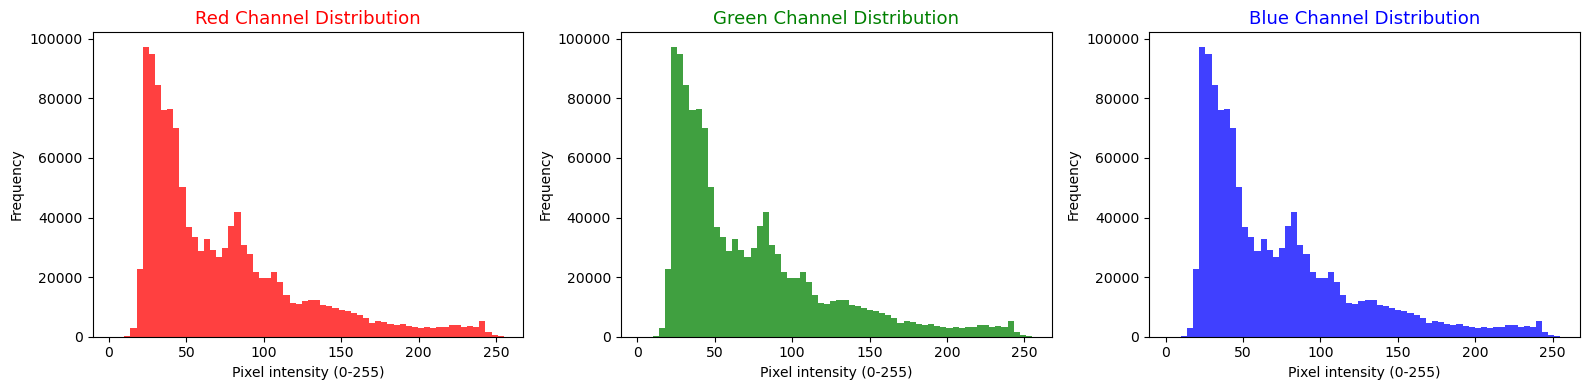

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (channel, color) in zip(axes, [('Red', 'red'), ('Green', 'green'), ('Blue', 'blue')]):
    ax.hist(df[channel], bins=64, color=color, alpha=0.75)
    ax.set_title(f'{channel} Channel Distribution', fontsize=13, color=color)
    ax.set_xlabel('Pixel intensity (0-255)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()